In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
data.describe()

,TimeStamp,Температура масла в магистрали общей откачки (поз. Тм),Температура слива масла из опоры турбины (поз. Т606),Температура масла на входе в двигатель за фильтром (поз. Т607),Температура топливного газа перед СК (перед расходомерным устройством) (поз. Ттг),Давление масла в нагнетающей магистрали двигателя (после фильтра) (поз. Pм),Давление масла в магистрали общей откачки (поз. Р615),Давление за ОК Pk1,Давление за ОК Pk2,Давление топливного газа перед дозаторами (поз. Pтг1.1),...,Частота вращения РНД (Расчетная),Частота вращения РВД (Расчетная),Частота вращения РСТ (Расчетная),Температура воздуха на входе в газогенератор (Расчетная),Давление воздуха за компрессором (Расчетная),Частота вращения РНД приведенная,Частота вращения РВД приведенная,Температура газов за ТНД максимальная (Расчетная),Положение лопаток НА КВД. (поз. A2),Положение КПВ (поз. A3)
count,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,...,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000,12659.000000
mean,29221.504937,33.339443,46.899381,23.551285,15.809396,306.086000,200.516337,664.464143,674.522635,2883.361420,...,6287.751512,10237.990568,2824.757244,4.811248,669.438733,6400.921047,10421.420551,524.133623,55.194629,8.610001
std,16984.583040,6.211664,10.560371,0.419254,4.737678,3.318548,9.837220,327.777803,325.571627,26.510501,...,1722.392158,518.779610,1040.317480,0.323773,326.684880,1756.239719,533.399588,70.713229,29.805948,0.233052
min,1.000000,21.548000,28.160000,23.061000,8.762000,300.575000,176.381000,242.863000,255.675000,2856.472000,...,4052.096000,9560.632000,1490.129000,4.206000,249.922000,4119.289000,9721.678000,437.730000,15.716000,7.917000
25%,14558.500000,28.545000,38.127000,23.247000,11.573000,301.965000,193.623000,248.643000,261.497000,2859.809000,...,4083.469000,9565.874000,1513.338000,4.543000,254.878000,4154.052000,9731.436000,439.895000,16.702000,8.454000
50%,29116.000000,33.543000,45.702000,23.316000,15.021000,308.028000,199.073000,933.531000,941.758000,2862.405000,...,7696.938000,10660.045000,3688.639000,4.729000,937.915000,7835.933000,10853.983000,580.933000,79.469000,8.589000
75%,43672.000000,38.621500,56.368000,23.920000,20.501000,308.825000,205.951000,938.424500,946.584000,2915.057000,...,7714.104000,10664.246000,3700.551000,5.113000,942.490500,7855.843500,10859.357000,587.176000,79.656000,8.803000
max,59998.000000,43.561000,65.943000,24.454000,23.477000,315.815000,233.574000,968.291000,975.618000,2918.642000,...,7804.798000,10721.832000,3709.335000,5.601000,971.878000,7948.316000,10918.990000,588.427000,80.900000,9.141000


In [ ]:
def noising(data, treshold):
    data = data.copy()
    treshold/=3
    noise = np.random.uniform(-treshold, treshold, size=len(data))
    new_data = data + noise
    return new_data.clip(upper=13000, lower=0.22)

def flatten(data, treshold):
    data = data.copy()
    zero = data.values[0]
    return data.apply(lambda x: zero)

def trembling(data, treshold):
    data = data.copy()
    periods = random.randint(10, 30)
    period = int(len(data)/periods)
    for i in range(periods):
        point = data.iloc[int(period*i)]
        new_point = point + random.uniform(-treshold, treshold)
        if new_point > 13000:
            new_point = 13000
        if new_point < 0.22:
            new_point = 0.22
        data.iloc[int(period*i) : int(period*(i+1)-1)] = new_point
    return data

def nothing(data, treshold):
    return data.copy()

In [ ]:
batches = 16
batch_len = int(12659/batches)

for column in data.columns[1:]:
    data[column] = data[column].astype(float)
    
    for i in range(batches):
        start = batch_len * i
        end = (batch_len * (i + 1) if i == batches - 1 else len(data)) - 1

        func = random.choice([noising, flatten, trembling, nothing, flatten, trembling, nothing, flatten, trembling, nothing, nothing])
        
        data.loc[start:end, column] = func(data.loc[start:end, column], 700).values

    data.loc[0:5000, column] = clear_data.loc[0:5000, column].values

'for column in data.columns[1:]:\n    data[column] = data[column].astype(float)\n\n    for i in range(batches):\n        func = random.choice([noising, flatten, trembling, nothing, flatten, trembling, nothing, flatten, trembling, nothing, nothing])\n        data.loc[batch_len*i:batch_len*(i+1), column] = func(data.loc[batch_len*i:batch_len*(i+1), column], 700).values'

In [74]:
data = pd.read_csv('data/1.csv', encoding='cp1251', sep=';')
data['TimeStamp'] = data['TimeStamp'].apply(lambda x: int(x[5:].replace(':','').replace('.','')))
clear_data = data.copy()
for column in clear_data.columns[1:]:
    # 1. Принудительно в float
    clear_data[column] = clear_data[column].astype(float)
data

,TimeStamp,Температура масла в магистрали общей откачки (поз. Тм),Температура слива масла из опоры турбины (поз. Т606),Температура масла на входе в двигатель за фильтром (поз. Т607),Температура топливного газа перед СК (перед расходомерным устройством) (поз. Ттг),Давление масла в нагнетающей магистрали двигателя (после фильтра) (поз. Pм),Давление масла в магистрали общей откачки (поз. Р615),Давление за ОК Pk1,Давление за ОК Pk2,Давление топливного газа перед дозаторами (поз. Pтг1.1),...,Частота вращения РНД (Расчетная),Частота вращения РВД (Расчетная),Частота вращения РСТ (Расчетная),Температура воздуха на входе в газогенератор (Расчетная),Давление воздуха за компрессором (Расчетная),Частота вращения РНД приведенная,Частота вращения РВД приведенная,Температура газов за ТНД максимальная (Расчетная),Положение лопаток НА КВД. (поз. A2),Положение КПВ (поз. A3)
0,1,21.548,28.160,24.361,8.762,302.095,198.239,244.713,257.590,2917.776,...,4052.990,9564.946,1490.427,5.601,250.959,4119.418,9722.291,439.119,16.139,8.072
1,24,21.548,28.160,24.361,8.762,302.095,198.239,244.713,257.590,2917.776,...,4053.209,9565.001,1490.403,5.601,251.152,4119.683,9722.339,439.119,16.139,8.072
2,46,21.548,28.160,24.361,8.762,302.559,198.220,243.865,258.663,2916.046,...,4053.209,9565.001,1490.403,5.601,251.152,4119.905,9722.395,439.119,15.876,7.931
3,68,21.548,28.160,24.361,8.762,302.559,198.220,243.865,258.663,2916.046,...,4053.079,9564.868,1490.337,5.601,251.264,4119.905,9722.395,439.107,15.876,7.931
4,91,21.548,28.230,24.361,8.762,302.262,197.553,243.865,257.820,2915.057,...,4053.079,9564.868,1490.337,5.601,251.264,4119.773,9722.260,439.107,15.758,7.931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12654,51044,43.561,65.943,23.177,23.477,308.473,199.926,935.612,941.988,2859.809,...,7699.703,10666.571,3697.968,4.822,939.183,7834.907,10856.534,586.625,79.420,9.020
12655,51064,43.561,65.943,23.107,23.477,308.473,199.926,933.762,942.065,2860.674,...,7700.150,10667.598,3698.198,4.822,938.800,7837.355,10857.264,586.625,79.667,9.014
12656,51087,43.561,65.943,23.107,23.477,308.473,199.926,933.762,942.065,2860.674,...,7701.266,10666.765,3698.287,4.822,937.913,7837.810,10858.309,586.625,79.667,9.014
12657,51111,43.561,65.943,23.107,23.477,308.232,200.667,934.841,942.065,2857.584,...,7701.266,10666.765,3698.287,4.822,937.913,7838.946,10857.461,586.625,79.637,8.975


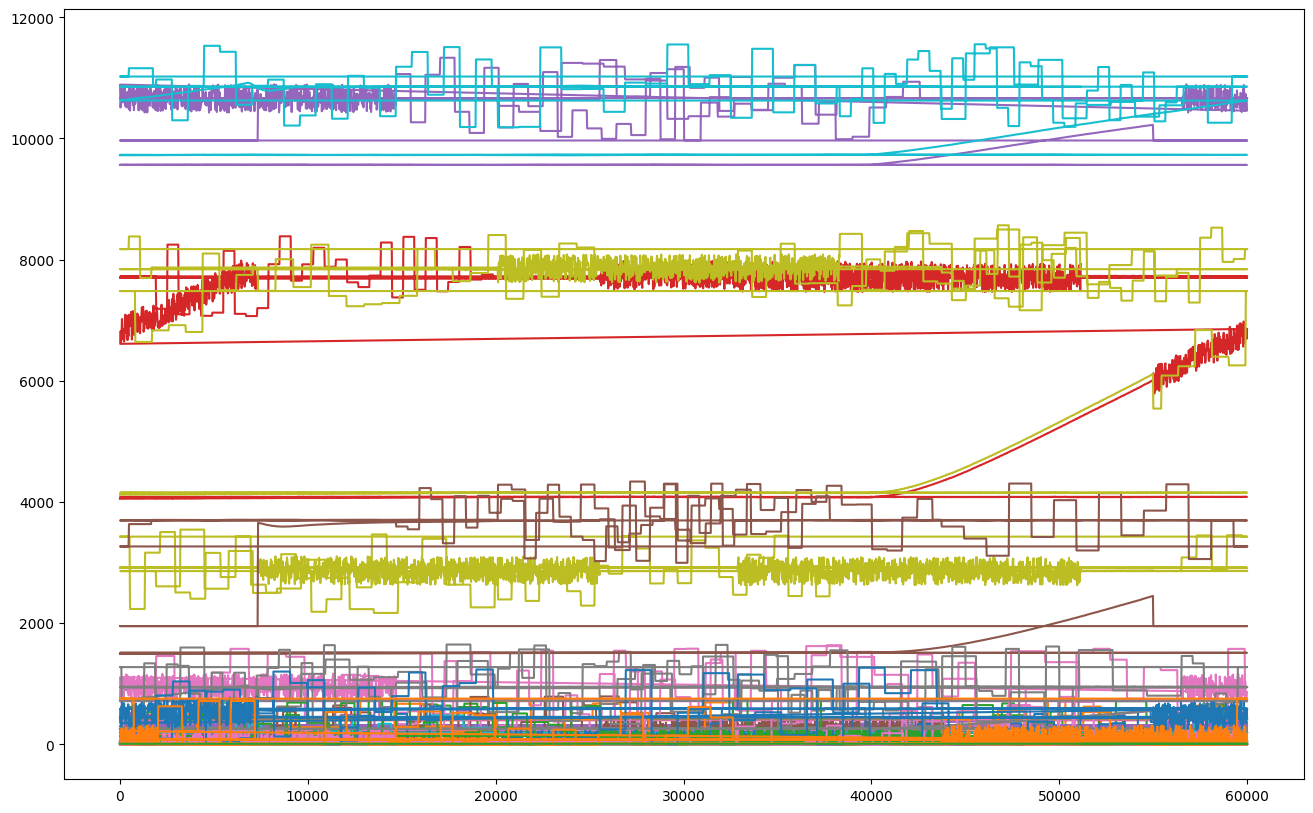

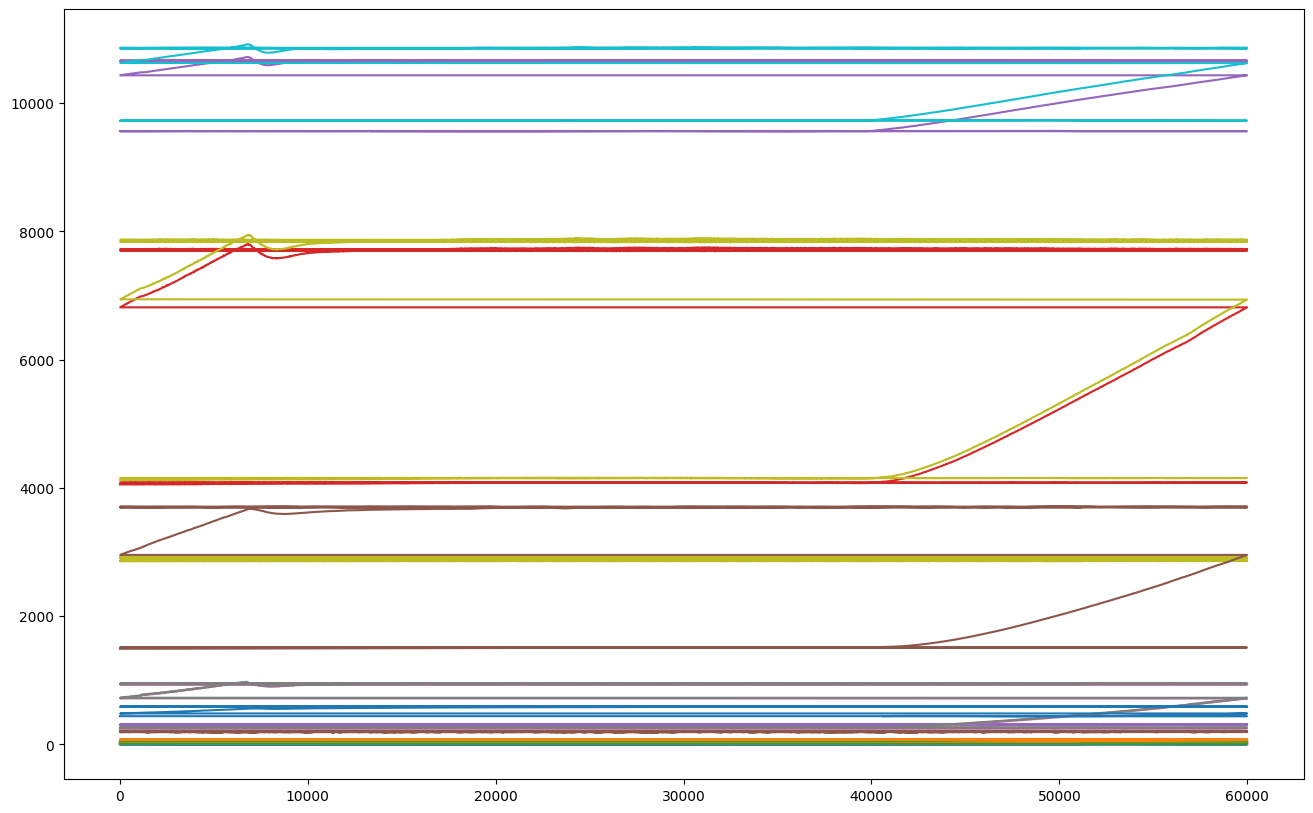

In [ ]:
plt.figure(figsize=(16, 10))
for i in data.columns[1:]:
    plt.plot(data['TimeStamp'], data[i])

plt.show()

plt.figure(figsize=(16, 10))
for i in clear_data.columns[1:]:
    plt.plot(clear_data['TimeStamp'], clear_data[i])

plt.show()

In [ ]:
for d in ('1', '2', '3', '4', '5'):
    try:    
        data = pd.read_csv('data/'+d+'.csv', encoding='cp1251', sep=';')
        data['TimeStamp'] = data['TimeStamp'].apply(lambda x: int(x[5:].replace(':','').replace('.','')))
        clear_data = data.copy()
        for column in clear_data.columns[1:]:
            clear_data[column] = clear_data[column].astype(float)

        batches = 16
        batch_len = int(12659/batches)

        for column in data.columns[1:]:
            data[column] = data[column].astype(float)
            
            for i in range(batches):
                start = batch_len * i
                end = (batch_len * (i + 1) if i == batches - 1 else len(data)) - 1

                func = random.choice([noising, flatten, trembling, nothing, flatten, trembling, nothing, flatten, trembling, nothing, nothing])
                
                data.loc[start:end, column] = func(data.loc[start:end, column], 700).values

            data.loc[0:5000, column] = clear_data.loc[0:5000, column].values

        plt.figure(figsize=(16, 10))
        for i in data.columns[1:]:
            plt.plot(data['TimeStamp'], data[i])
        plt.title(d+'.csv')
        plt.show()

        plt.figure(figsize=(16, 10))
        for i in clear_data.columns[1:]:
            plt.plot(clear_data['TimeStamp'], clear_data[i])

        plt.show()

        data.to_csv('data/distorted_'+d+'.csv')
    except:
        print('не удолось преобразовать файл '+d+'.csv')